# 🚀 Day 1: Engineering Foundations + Quantum State Formalism

## 14-Day Quantum DevRel Bootcamp

**Goal:** Build solid Python engineering skills AND master single-qubit quantum mechanics.

**Today's Deliverables:**
1. ✅ Function that normalizes a complex vector
2. ✅ Function that checks if a matrix is unitary
3. ✅ Manual tensor product implementation
4. ✅ Single qubit operations with gates
5. ✅ Bloch sphere visualization

---

## Block 1: Python Environment Setup

In [1]:
# Essential imports for quantum computing
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from typing import Tuple

# Verify environment
print("✅ NumPy version:", np.__version__)
print("✅ Environment ready for quantum computing!")
print()
print("Key numpy functions we'll use:")
print("  - np.array: Create vectors and matrices")
print("  - np.linalg.norm: Compute vector norms")
print("  - np.allclose: Compare matrices within tolerance")
print("  - np.kron: Tensor product (but we'll implement manually first!)")
print("  - @ operator: Matrix multiplication")

Matplotlib is building the font cache; this may take a moment.


✅ NumPy version: 2.4.2
✅ Environment ready for quantum computing!

Key numpy functions we'll use:
  - np.array: Create vectors and matrices
  - np.linalg.norm: Compute vector norms
  - np.allclose: Compare matrices within tolerance
  - np.kron: Tensor product (but we'll implement manually first!)
  - @ operator: Matrix multiplication


---
## Section 1: Complex Vector Normalization

In quantum mechanics, state vectors must be **normalized** (unit length).

For a vector $|\psi\rangle = [\alpha_0, \alpha_1, ..., \alpha_n]^T$:

$$\||\psi\rangle\| = \sqrt{\sum_i |\alpha_i|^2} = 1$$

The normalized vector is: $|\hat{\psi}\rangle = \frac{|\psi\rangle}{\||\psi\rangle\|}$

### Why normalization matters:
- The squared magnitudes $|\alpha_i|^2$ represent **probabilities**
- Probabilities must sum to 1 (Born rule)
- This is the fundamental link between quantum amplitudes and observable outcomes

In [2]:
def normalize_vector(v: np.ndarray) -> np.ndarray:
    """
    Normalize a complex vector to have unit length.
    
    Args:
        v: A complex numpy array representing the vector
        
    Returns:
        The normalized vector (same direction, unit length)
    """
    norm = np.linalg.norm(v)  # Works correctly for complex numbers
    
    if norm == 0:
        raise ValueError("Cannot normalize zero vector")
    
    return v / norm


# Test the function
print("🧪 Testing normalize_vector()")
print("=" * 50)

# Test 1: Simple complex vector
v1 = np.array([3+4j, 0])
v1_normalized = normalize_vector(v1)
print(f"Original:   {v1}")
print(f"Normalized: {v1_normalized}")
print(f"Norm check: {np.linalg.norm(v1_normalized):.6f}")
print()

# Test 2: Vector that needs normalization
v2 = np.array([1, 1, 1, 1], dtype=complex)
v2_normalized = normalize_vector(v2)
print(f"Original:   {v2}")
print(f"Normalized: {v2_normalized}")
print(f"Norm check: {np.linalg.norm(v2_normalized):.6f}")
print()

# Test 3: Quantum superposition state
v3 = np.array([1, 1], dtype=complex)  # |0⟩ + |1⟩ (unnormalized)
v3_normalized = normalize_vector(v3)
print(f"Original:   {v3} (= |0⟩ + |1⟩, unnormalized)")
print(f"Normalized: {v3_normalized} (= |+⟩ state)")
print(f"Norm check: {np.linalg.norm(v3_normalized):.6f}")

🧪 Testing normalize_vector()
Original:   [3.+4.j 0.+0.j]
Normalized: [0.6+0.8j 0. +0.j ]
Norm check: 1.000000

Original:   [1.+0.j 1.+0.j 1.+0.j 1.+0.j]
Normalized: [0.5+0.j 0.5+0.j 0.5+0.j 0.5+0.j]
Norm check: 1.000000

Original:   [1.+0.j 1.+0.j] (= |0⟩ + |1⟩, unnormalized)
Normalized: [0.70710678+0.j 0.70710678+0.j] (= |+⟩ state)
Norm check: 1.000000


---
## Section 2: Unitary Matrix Verification

Quantum gates are represented by **unitary matrices**.

A matrix $U$ is unitary if: $U^\dagger U = UU^\dagger = I$

Where $U^\dagger$ is the **conjugate transpose** (Hermitian adjoint).

### Why unitary matrices matter in quantum computing:
1. **Reversibility**: $U^{-1} = U^\dagger$ (always invertible)
2. **Norm preservation**: $\||U|\psi\rangle\|| = \||\psi\rangle\||$ (probabilities stay valid)
3. **Eigenvalues on unit circle**: All eigenvalues have $|\lambda| = 1$

In [3]:
def is_unitary(U: np.ndarray, tolerance: float = 1e-10) -> bool:
    """
    Check if a matrix U is unitary (U†U = I).
    
    Args:
        U: A square complex numpy matrix
        tolerance: Maximum allowed deviation from identity
        
    Returns:
        True if U is unitary within tolerance, False otherwise
    """
    # Compute conjugate transpose: U†
    U_dagger = U.conj().T
    
    # Compute U†U
    product = U_dagger @ U
    
    # Compare to identity matrix
    identity = np.eye(U.shape[0], dtype=complex)
    
    return np.allclose(product, identity, atol=tolerance)


# Test with common quantum gates
print("🧪 Testing is_unitary()")
print("=" * 50)

# Hadamard gate - should be unitary
H = (1/np.sqrt(2)) * np.array([[1, 1], [1, -1]], dtype=complex)
print(f"Hadamard gate H:")
print(H)
print(f"Is unitary: {is_unitary(H)} ✅")
print()

# Pauli-X gate - should be unitary
X = np.array([[0, 1], [1, 0]], dtype=complex)
print(f"Pauli-X gate:")
print(X)
print(f"Is unitary: {is_unitary(X)} ✅")
print()

# Pauli-Z gate - should be unitary
Z = np.array([[1, 0], [0, -1]], dtype=complex)
print(f"Pauli-Z gate:")
print(Z)
print(f"Is unitary: {is_unitary(Z)} ✅")
print()

# Non-unitary matrix for contrast
non_unitary = np.array([[1, 1], [0, 1]], dtype=complex)
print(f"Non-unitary matrix [[1,1],[0,1]]:")
print(non_unitary)
print(f"Is unitary: {is_unitary(non_unitary)} ❌")
print()

# Verify by computing U†U for non-unitary
print("Why it's not unitary:")
print("U†U =")
print(non_unitary.conj().T @ non_unitary)
print("(Not equal to identity!)")

🧪 Testing is_unitary()
Hadamard gate H:
[[ 0.70710678+0.j  0.70710678+0.j]
 [ 0.70710678+0.j -0.70710678+0.j]]
Is unitary: True ✅

Pauli-X gate:
[[0.+0.j 1.+0.j]
 [1.+0.j 0.+0.j]]
Is unitary: True ✅

Pauli-Z gate:
[[ 1.+0.j  0.+0.j]
 [ 0.+0.j -1.+0.j]]
Is unitary: True ✅

Non-unitary matrix [[1,1],[0,1]]:
[[1.+0.j 1.+0.j]
 [0.+0.j 1.+0.j]]
Is unitary: False ❌

Why it's not unitary:
U†U =
[[1.+0.j 1.+0.j]
 [1.+0.j 2.+0.j]]
(Not equal to identity!)


---
## Section 3: Manual Tensor Product Implementation

The **tensor product** (Kronecker product) is FUNDAMENTAL to quantum computing.

For vectors $|a\rangle$ and $|b\rangle$:
$$|a\rangle \otimes |b\rangle = [a_0|b\rangle, a_1|b\rangle, ...]^T$$

### Why tensor products are ESSENTIAL:
- Single qubit: lives in $\mathbb{C}^2$ (2D complex vector space)
- Two qubits: live in $\mathbb{C}^2 \otimes \mathbb{C}^2 = \mathbb{C}^4$ (NOT $\mathbb{C}^2 + \mathbb{C}^2$!)
- n qubits: live in $\mathbb{C}^{2^n}$

This **exponential growth** is the source of quantum computational power!

### Key insight about entanglement:
Not all states in $\mathbb{C}^4$ can be written as $|a\rangle \otimes |b\rangle$.  
Those that cannot are called **ENTANGLED**!

In [4]:
def tensor_product(A: np.ndarray, B: np.ndarray) -> np.ndarray:
    """
    Compute the tensor product (Kronecker product) manually.
    
    For vectors a ∈ ℂᵐ and b ∈ ℂⁿ:
    a ⊗ b = [a₀b, a₁b, ..., aₘ₋₁b]ᵀ ∈ ℂᵐⁿ
    
    For matrices A (m×n) and B (p×q):
    A ⊗ B is (mp×nq) where each element A[i,j] is replaced by A[i,j]*B
    
    Args:
        A: First matrix/vector
        B: Second matrix/vector
        
    Returns:
        The tensor product A ⊗ B
    """
    # Handle 1D arrays (vectors) - convert to 2D
    A = np.atleast_2d(A)
    B = np.atleast_2d(B)
    
    # Track if inputs were vectors for proper output shape
    a_was_1d = A.shape[0] == 1 or A.shape[1] == 1
    b_was_1d = B.shape[0] == 1 or B.shape[1] == 1
    
    m, n = A.shape
    p, q = B.shape
    
    # Result will be (m*p) × (n*q)
    result = np.zeros((m * p, n * q), dtype=complex)
    
    # Fill in blocks: place A[i,j] * B in each block position
    for i in range(m):
        for j in range(n):
            row_start = i * p
            row_end = (i + 1) * p
            col_start = j * q
            col_end = (j + 1) * q
            
            result[row_start:row_end, col_start:col_end] = A[i, j] * B
    
    # If both inputs were vectors, flatten output
    if a_was_1d and b_was_1d:
        return result.flatten()
    
    return result


# Test the tensor product implementation
print("🧪 Testing tensor_product()")
print("=" * 50)

# Define computational basis states
ket0 = np.array([1, 0], dtype=complex)  # |0⟩
ket1 = np.array([0, 1], dtype=complex)  # |1⟩

print("Computational basis states:")
print(f"|0⟩ = {ket0}")
print(f"|1⟩ = {ket1}")
print()

# Two-qubit basis states
print("Two-qubit basis states via tensor product:")
print(f"|0⟩ ⊗ |0⟩ = |00⟩ = {tensor_product(ket0, ket0)}")
print(f"|0⟩ ⊗ |1⟩ = |01⟩ = {tensor_product(ket0, ket1)}")
print(f"|1⟩ ⊗ |0⟩ = |10⟩ = {tensor_product(ket1, ket0)}")
print(f"|1⟩ ⊗ |1⟩ = |11⟩ = {tensor_product(ket1, ket1)}")
print()

# Verify against numpy's kron
print("Verification against np.kron:")
test_result = tensor_product(ket0, ket1)
numpy_result = np.kron(ket0, ket1)
print(f"Our result:     {test_result}")
print(f"np.kron result: {numpy_result}")
print(f"Match: {np.allclose(test_result, numpy_result)} ✅")

🧪 Testing tensor_product()
Computational basis states:
|0⟩ = [1.+0.j 0.+0.j]
|1⟩ = [0.+0.j 1.+0.j]

Two-qubit basis states via tensor product:
|0⟩ ⊗ |0⟩ = |00⟩ = [1.+0.j 0.+0.j 0.+0.j 0.+0.j]
|0⟩ ⊗ |1⟩ = |01⟩ = [0.+0.j 1.+0.j 0.+0.j 0.+0.j]
|1⟩ ⊗ |0⟩ = |10⟩ = [0.+0.j 0.+0.j 1.+0.j 0.+0.j]
|1⟩ ⊗ |1⟩ = |11⟩ = [0.+0.j 0.+0.j 0.+0.j 1.+0.j]

Verification against np.kron:
Our result:     [0.+0.j 1.+0.j 0.+0.j 0.+0.j]
np.kron result: [0.+0.j 1.+0.j 0.+0.j 0.+0.j]
Match: True ✅


---
## Section 4: Single Qubit State Representation

A **qubit** is the fundamental unit of quantum information.

Mathematically, a qubit is a unit vector in $\mathbb{C}^2$:

$$|\psi\rangle = \alpha|0\rangle + \beta|1\rangle$$

Where:
- $|0\rangle = [1, 0]^T$ (computational basis state "zero")
- $|1\rangle = [0, 1]^T$ (computational basis state "one")  
- $\alpha, \beta \in \mathbb{C}$ (complex amplitudes)
- $|\alpha|^2 + |\beta|^2 = 1$ (normalization constraint)

### Key differences from classical bits:
1. Classical bit: either 0 OR 1
2. Qubit: can be in **superposition** (both 0 AND 1 simultaneously)
3. Amplitudes are **complex** (have phase!)
4. Measurement **collapses** the state probabilistically

In [5]:
# Define computational basis states
KET_0 = np.array([1, 0], dtype=complex)
KET_1 = np.array([0, 1], dtype=complex)

def create_qubit(alpha: complex, beta: complex, normalize: bool = True) -> np.ndarray:
    """
    Create a qubit state |ψ⟩ = α|0⟩ + β|1⟩.
    
    Args:
        alpha: Amplitude for |0⟩
        beta: Amplitude for |1⟩
        normalize: If True, automatically normalize the state
        
    Returns:
        Normalized qubit state vector
    """
    state = np.array([alpha, beta], dtype=complex)
    
    if normalize:
        norm = np.linalg.norm(state)
        if norm == 0:
            raise ValueError("Cannot create zero-norm state")
        state = state / norm
    
    return state


# Create some common qubit states
print("📊 Common Qubit States")
print("=" * 50)

# Computational basis
print("Computational Basis:")
print(f"|0⟩ = {KET_0}")
print(f"|1⟩ = {KET_1}")
print()

# Equal superposition states
plus = create_qubit(1, 1)   # (|0⟩ + |1⟩)/√2
minus = create_qubit(1, -1) # (|0⟩ - |1⟩)/√2

print("Hadamard Basis (equal superpositions):")
print(f"|+⟩ = (|0⟩ + |1⟩)/√2 = {plus}")
print(f"|-⟩ = (|0⟩ - |1⟩)/√2 = {minus}")
print()

# States with imaginary components
plus_i = create_qubit(1, 1j)  # (|0⟩ + i|1⟩)/√2
minus_i = create_qubit(1, -1j) # (|0⟩ - i|1⟩)/√2

print("Circular Basis (imaginary phase):")
print(f"|+i⟩ = (|0⟩ + i|1⟩)/√2 = {plus_i}")
print(f"|-i⟩ = (|0⟩ - i|1⟩)/√2 = {minus_i}")

📊 Common Qubit States
Computational Basis:
|0⟩ = [1.+0.j 0.+0.j]
|1⟩ = [0.+0.j 1.+0.j]

Hadamard Basis (equal superpositions):
|+⟩ = (|0⟩ + |1⟩)/√2 = [0.70710678+0.j 0.70710678+0.j]
|-⟩ = (|0⟩ - |1⟩)/√2 = [ 0.70710678+0.j -0.70710678+0.j]

Circular Basis (imaginary phase):
|+i⟩ = (|0⟩ + i|1⟩)/√2 = [0.70710678+0.j         0.        +0.70710678j]
|-i⟩ = (|0⟩ - i|1⟩)/√2 = [ 0.70710678+0.j         -0.        -0.70710678j]


---
## Section 5: Pauli and Hadamard Gate Operations

Quantum gates are **unitary transformations** represented by matrices.

### The Pauli Gates (Single-Qubit):

**Pauli-X (NOT gate / bit-flip):**
$$X = \begin{pmatrix} 0 & 1 \\ 1 & 0 \end{pmatrix}, \quad X|0\rangle = |1\rangle, \quad X|1\rangle = |0\rangle$$

**Pauli-Y:**
$$Y = \begin{pmatrix} 0 & -i \\ i & 0 \end{pmatrix}$$

**Pauli-Z (phase-flip):**
$$Z = \begin{pmatrix} 1 & 0 \\ 0 & -1 \end{pmatrix}, \quad Z|0\rangle = |0\rangle, \quad Z|1\rangle = -|1\rangle$$

### The Hadamard Gate (creates superposition):
$$H = \frac{1}{\sqrt{2}}\begin{pmatrix} 1 & 1 \\ 1 & -1 \end{pmatrix}, \quad H|0\rangle = |+\rangle, \quad H|1\rangle = |-\rangle$$

In [6]:
# Define quantum gates as matrices
PAULI_X = np.array([[0, 1], [1, 0]], dtype=complex)
PAULI_Y = np.array([[0, -1j], [1j, 0]], dtype=complex)
PAULI_Z = np.array([[1, 0], [0, -1]], dtype=complex)
HADAMARD = (1/np.sqrt(2)) * np.array([[1, 1], [1, -1]], dtype=complex)
IDENTITY = np.array([[1, 0], [0, 1]], dtype=complex)

def apply_gate(gate: np.ndarray, state: np.ndarray) -> np.ndarray:
    """Apply a quantum gate (unitary matrix) to a qubit state."""
    return gate @ state


print("🔧 Quantum Gate Operations")
print("=" * 50)

# Pauli-X: Bit flip
print("1️⃣ Pauli-X (bit flip):")
print(f"   X|0⟩ = {apply_gate(PAULI_X, KET_0)} = |1⟩ ✅")
print(f"   X|1⟩ = {apply_gate(PAULI_X, KET_1)} = |0⟩ ✅")
print()

# Pauli-Z: Phase flip
print("2️⃣ Pauli-Z (phase flip):")
print(f"   Z|0⟩ = {apply_gate(PAULI_Z, KET_0)} = |0⟩ ✅ (unchanged)")
print(f"   Z|1⟩ = {apply_gate(PAULI_Z, KET_1)} = -|1⟩ ✅ (phase flipped)")
print()

# Hadamard: Creates superposition
print("3️⃣ Hadamard (creates superposition):")
print(f"   H|0⟩ = {apply_gate(HADAMARD, KET_0)} = |+⟩ ✅")
print(f"   H|1⟩ = {apply_gate(HADAMARD, KET_1)} = |-⟩ ✅")
print()

# Key property: H² = I
print("4️⃣ Important: H² = I (Hadamard is its own inverse)")
hh = HADAMARD @ HADAMARD
print(f"   H×H =")
print(f"   {hh}")
print(f"   H×H = I? {np.allclose(hh, IDENTITY)} ✅")
print()

# Verify all gates are unitary
print("5️⃣ All gates are unitary:")
print(f"   X is unitary: {is_unitary(PAULI_X)} ✅")
print(f"   Y is unitary: {is_unitary(PAULI_Y)} ✅")
print(f"   Z is unitary: {is_unitary(PAULI_Z)} ✅")
print(f"   H is unitary: {is_unitary(HADAMARD)} ✅")

🔧 Quantum Gate Operations
1️⃣ Pauli-X (bit flip):
   X|0⟩ = [0.+0.j 1.+0.j] = |1⟩ ✅
   X|1⟩ = [1.+0.j 0.+0.j] = |0⟩ ✅

2️⃣ Pauli-Z (phase flip):
   Z|0⟩ = [1.+0.j 0.+0.j] = |0⟩ ✅ (unchanged)
   Z|1⟩ = [ 0.+0.j -1.+0.j] = -|1⟩ ✅ (phase flipped)

3️⃣ Hadamard (creates superposition):
   H|0⟩ = [0.70710678+0.j 0.70710678+0.j] = |+⟩ ✅
   H|1⟩ = [ 0.70710678+0.j -0.70710678+0.j] = |-⟩ ✅

4️⃣ Important: H² = I (Hadamard is its own inverse)
   H×H =
   [[ 1.00000000e+00+0.j -2.23711432e-17+0.j]
 [-2.23711432e-17+0.j  1.00000000e+00+0.j]]
   H×H = I? True ✅

5️⃣ All gates are unitary:
   X is unitary: True ✅
   Y is unitary: True ✅
   Z is unitary: True ✅
   H is unitary: True ✅


---
## Section 6: Measurement Probability Computation

When we **measure** a qubit in the computational basis, we get classical outcomes.

### Born's Rule:
For state $|\psi\rangle = \alpha|0\rangle + \beta|1\rangle$:

$$P(|0\rangle) = |\alpha|^2, \quad P(|1\rangle) = |\beta|^2$$

This is THE fundamental connection between quantum amplitudes and observable classical outcomes.

### Key insight:
- **Before measurement**: Qubit is in superposition (both 0 and 1)
- **After measurement**: Qubit collapses to |0⟩ or |1⟩
- **Measurement is irreversible**: Original superposition is lost

In [7]:
def measurement_probabilities(state: np.ndarray) -> dict:
    """
    Calculate probabilities of measuring |0⟩ and |1⟩.
    
    Born Rule: P(outcome) = |amplitude|²
    
    Args:
        state: A normalized qubit state vector
        
    Returns:
        Dictionary with P(0) and P(1)
    """
    prob_0 = np.abs(state[0])**2
    prob_1 = np.abs(state[1])**2
    return {'P(|0⟩)': prob_0, 'P(|1⟩)': prob_1, 'Sum': prob_0 + prob_1}


print("📊 Measurement Probabilities")
print("=" * 50)

# |0⟩ state: Always measures 0
print("State: |0⟩")
print(f"  {measurement_probabilities(KET_0)}")
print("  → Always measures 0")
print()

# |1⟩ state: Always measures 1
print("State: |1⟩")
print(f"  {measurement_probabilities(KET_1)}")
print("  → Always measures 1")
print()

# |+⟩ state: 50/50 superposition
plus = create_qubit(1, 1)
print("State: |+⟩ = (|0⟩ + |1⟩)/√2")
print(f"  {measurement_probabilities(plus)}")
print("  → 50% chance of 0, 50% chance of 1")
print()

# |-⟩ state: Also 50/50 (but different phase!)
minus = create_qubit(1, -1)
print("State: |-⟩ = (|0⟩ - |1⟩)/√2")
print(f"  {measurement_probabilities(minus)}")
print("  → Same probabilities as |+⟩! (Phase doesn't affect direct measurement)")
print()

# Arbitrary state
arbitrary = create_qubit(1, 2)
print("State: (|0⟩ + 2|1⟩)/√5")
print(f"  {measurement_probabilities(arbitrary)}")
print("  → Biased toward |1⟩")
print()

# Phase doesn't affect probabilities in computational basis
state_with_phase = create_qubit(1, np.exp(1j * np.pi/4))
print("State: (|0⟩ + e^(iπ/4)|1⟩)/√2")
print(f"  {measurement_probabilities(state_with_phase)}")
print("  → Still 50/50! Complex phase doesn't affect |amplitude|²")

📊 Measurement Probabilities
State: |0⟩
  {'P(|0⟩)': np.float64(1.0), 'P(|1⟩)': np.float64(0.0), 'Sum': np.float64(1.0)}
  → Always measures 0

State: |1⟩
  {'P(|0⟩)': np.float64(0.0), 'P(|1⟩)': np.float64(1.0), 'Sum': np.float64(1.0)}
  → Always measures 1

State: |+⟩ = (|0⟩ + |1⟩)/√2
  {'P(|0⟩)': np.float64(0.4999999999999999), 'P(|1⟩)': np.float64(0.4999999999999999), 'Sum': np.float64(0.9999999999999998)}
  → 50% chance of 0, 50% chance of 1

State: |-⟩ = (|0⟩ - |1⟩)/√2
  {'P(|0⟩)': np.float64(0.4999999999999999), 'P(|1⟩)': np.float64(0.4999999999999999), 'Sum': np.float64(0.9999999999999998)}
  → Same probabilities as |+⟩! (Phase doesn't affect direct measurement)

State: (|0⟩ + 2|1⟩)/√5
  {'P(|0⟩)': np.float64(0.19999999999999998), 'P(|1⟩)': np.float64(0.7999999999999999), 'Sum': np.float64(0.9999999999999999)}
  → Biased toward |1⟩

State: (|0⟩ + e^(iπ/4)|1⟩)/√2
  {'P(|0⟩)': np.float64(0.4999999999999999), 'P(|1⟩)': np.float64(0.4999999999999999), 'Sum': np.float64(0.999999999999

---
## Section 7: Bloch Sphere Visualization

The **Bloch sphere** is a beautiful geometric representation of single-qubit states.

Any pure single-qubit state can be written as:
$$|\psi\rangle = \cos(\theta/2)|0\rangle + e^{i\phi}\sin(\theta/2)|1\rangle$$

Where:
- $\theta \in [0, \pi]$ (polar angle from +Z axis)
- $\phi \in [0, 2\pi)$ (azimuthal angle in XY plane)

### Special points on the Bloch sphere:
| State | Coordinates |
|-------|-------------|
| $\|0\rangle$ | North pole (0, 0, 1) |
| $\|1\rangle$ | South pole (0, 0, -1) |
| $\|+\rangle$ | +X axis (1, 0, 0) |
| $\|-\rangle$ | -X axis (-1, 0, 0) |
| $\|+i\rangle$ | +Y axis (0, 1, 0) |
| $\|-i\rangle$ | -Y axis (0, -1, 0) |

### Why the Bloch sphere works:
- Global phase doesn't matter: $e^{i\gamma}|\psi\rangle$ is the same state as $|\psi\rangle$
- Normalization uses up one degree of freedom
- So 2 complex numbers (4 real) → 2 real parameters (θ, φ)

In [15]:
# Import plotly for interactive 3D visualization
import plotly.graph_objects as go

print("✅ Plotly loaded for interactive 3D visualization!")
print("The Bloch sphere below will be fully interactive:")
print("  • Click and drag to rotate")
print("  • Scroll to zoom in/out")
print("  • Double-click to reset view")

✅ Plotly loaded for interactive 3D visualization!
The Bloch sphere below will be fully interactive:
  • Click and drag to rotate
  • Scroll to zoom in/out
  • Double-click to reset view


🌐 Bloch Sphere Coordinates
|0⟩: (x=0.00, y=0.00, z=1.00)
|1⟩: (x=0.00, y=0.00, z=-1.00)
|+⟩: (x=1.00, y=0.00, z=-0.00)
|-⟩: (x=-1.00, y=0.00, z=-0.00)
|+i⟩: (x=0.00, y=1.00, z=0.00)
|-i⟩: (x=0.00, y=-1.00, z=0.00)


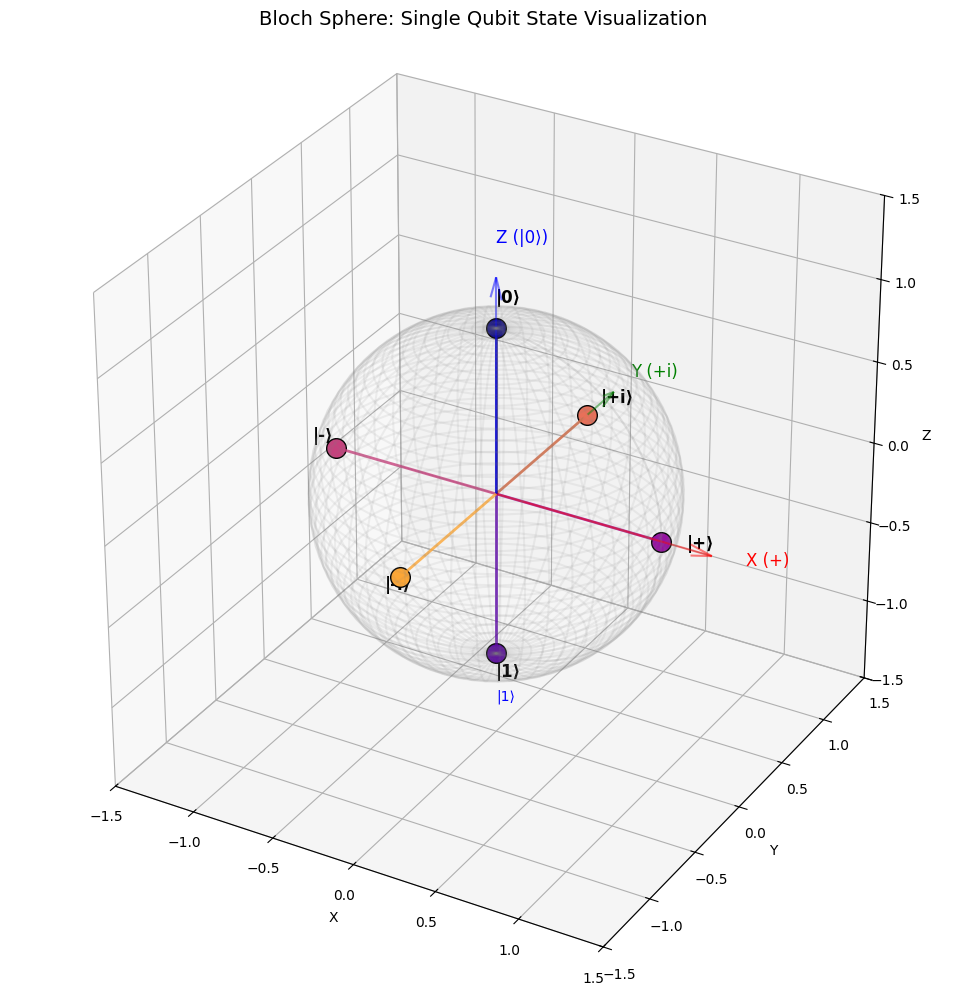

In [ ]:
def state_to_bloch(state: np.ndarray) -> Tuple[float, float, float]:
    """
    Convert qubit state to Bloch sphere coordinates (x, y, z).
    
    The Bloch vector components are expectation values of Pauli matrices:
    x = ⟨ψ|X|ψ⟩
    y = ⟨ψ|Y|ψ⟩  
    z = ⟨ψ|Z|ψ⟩
    """
    x = np.real(np.conj(state) @ PAULI_X @ state)
    y = np.real(np.conj(state) @ PAULI_Y @ state)
    z = np.real(np.conj(state) @ PAULI_Z @ state)
    return (x, y, z)


def bloch_to_state(theta: float, phi: float) -> np.ndarray:
    """
    Convert Bloch sphere angles to qubit state.
    
    |ψ⟩ = cos(θ/2)|0⟩ + e^(iφ)sin(θ/2)|1⟩
    """
    alpha = np.cos(theta / 2)
    beta = np.exp(1j * phi) * np.sin(theta / 2)
    return np.array([alpha, beta], dtype=complex)


def plot_bloch_sphere(states: list, labels: list = None):
    """Visualize qubit states on the Bloch sphere with interactive rotation."""
    # Create sphere surface
    u = np.linspace(0, 2 * np.pi, 30)
    v = np.linspace(0, np.pi, 30)
    x_sphere = np.outer(np.cos(u), np.sin(v))
    y_sphere = np.outer(np.sin(u), np.sin(v))
    z_sphere = np.outer(np.ones(np.size(u)), np.cos(v))
    
    fig = go.Figure()
    
    # Add transparent sphere surface
    fig.add_trace(go.Surface(
        x=x_sphere, y=y_sphere, z=z_sphere,
        opacity=0.15,
        colorscale=[[0, 'lightgray'], [1, 'lightgray']],
        showscale=False,
        hoverinfo='skip'
    ))
    
    # Add coordinate axes
    axis_length = 1.3
    axes_data = [
        ([0, axis_length], [0, 0], [0, 0], 'red', 'X (+)'),
        ([0, -axis_length], [0, 0], [0, 0], 'red', 'X (-)'),
        ([0, 0], [0, axis_length], [0, 0], 'green', 'Y (+i)'),
        ([0, 0], [0, -axis_length], [0, 0], 'green', 'Y (-)'),
        ([0, 0], [0, 0], [0, axis_length], 'blue', 'Z (|0⟩)'),
        ([0, 0], [0, 0], [0, -axis_length], 'blue', 'Z (|1⟩)')
    ]
    
    for x_ax, y_ax, z_ax, color, name in axes_data:
        fig.add_trace(go.Scatter3d(
            x=x_ax, y=y_ax, z=z_ax,
            mode='lines',
            line=dict(color=color, width=3),
            showlegend=False,
            hoverinfo='skip'
        ))
    
    # Plot state vectors
    colors_list = ['#440154', '#31688e', '#35b779', '#fde724', '#ff6e3a', '#c44569']
    
    for i, state in enumerate(states):
        coords = state_to_bloch(state)
        color = colors_list[i % len(colors_list)]
        label = labels[i] if labels else f'State {i}'
        
        # Add vector arrow
        fig.add_trace(go.Scatter3d(
            x=[0, coords[0]], 
            y=[0, coords[1]], 
            z=[0, coords[2]],
            mode='lines+markers',
            line=dict(color=color, width=6),
            marker=dict(size=[0, 10], color=color),
            name=label,
            hovertemplate=f'<b>{label}</b><br>x: %{{x:.3f}}<br>y: %{{y:.3f}}<br>z: %{{z:.3f}}<extra></extra>'
        ))
    
    # Configure layout
    fig.update_layout(
        title='Bloch Sphere: Interactive Single Qubit State Visualization',
        scene=dict(
            xaxis=dict(range=[-1.5, 1.5], title='X'),
            yaxis=dict(range=[-1.5, 1.5], title='Y'),
            zaxis=dict(range=[-1.5, 1.5], title='Z'),
            aspectmode='cube'
        ),
        width=800,
        height=800,
        showlegend=True
    )
    
    return fig


# Calculate Bloch coordinates for key states
print("🌐 Bloch Sphere Coordinates")
print("=" * 50)

states_to_plot = [KET_0, KET_1, plus, minus, plus_i, minus_i]
labels = ['|0⟩', '|1⟩', '|+⟩', '|-⟩', '|+i⟩', '|-i⟩']

for state, label in zip(states_to_plot, labels):
    coords = state_to_bloch(state)
    print(f"{label}: (x={coords[0]:.2f}, y={coords[1]:.2f}, z={coords[2]:.2f})")

# Plot the Bloch sphere (fully interactive!)
fig = plot_bloch_sphere(states_to_plot, labels)
fig.show()

---
## 🎯 Day 1 Summary & Deliverables

### What you learned today:
1. **Vector Normalization** - Ensuring quantum states have unit length
2. **Unitary Matrices** - Why quantum gates must be unitary
3. **Tensor Products** - How composite quantum systems are constructed
4. **Single Qubit States** - Representation as vectors in ℂ²
5. **Quantum Gates** - Pauli and Hadamard operations
6. **Born's Rule** - Computing measurement probabilities
7. **Bloch Sphere** - Geometric visualization of qubit states

### Your deliverables:
- ✅ `normalize_vector()` function
- ✅ `is_unitary()` function  
- ✅ `tensor_product()` function (manual implementation)
- ✅ Portfolio artifact: "Why a Qubit is NOT a Probabilistic Bit"

### Key takeaway for interviews:
> "A qubit is not probabilistic—it is in a genuine superposition with complex amplitudes that can interfere. This interference is the source of quantum computational power."

---
**Tomorrow (Day 2):** Single-qubit rotations in Qiskit, Bloch sphere visualizations with real SDK